## Canny: To get image edges

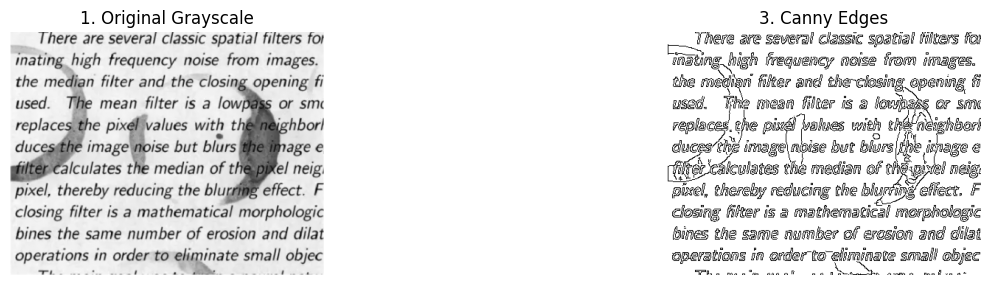

In [13]:
import cv2
import matplotlib.pyplot as plt

# 1. Load the dirty image in grayscale
image = cv2.imread('dirty-img.png', cv2.IMREAD_GRAYSCALE)

# 3. Apply Canny Edge Detection
edges = cv2.Canny(image, 40, 130)

final_result = cv2.bitwise_not(edges)

# 4. Display using Matplotlib
plt.figure(figsize=(10, 5))

# Subplot 1: Original Grayscale
plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('1. Original Grayscale')
plt.axis('off')


# Subplot 3: Canny Edges
plt.subplot(1, 3, 3)
plt.imshow(final_result, cmap='gray')
plt.title('3. Canny Edges')
plt.axis('off')

plt.tight_layout()
plt.show()

Using thresholds: Lower=152, Upper=255


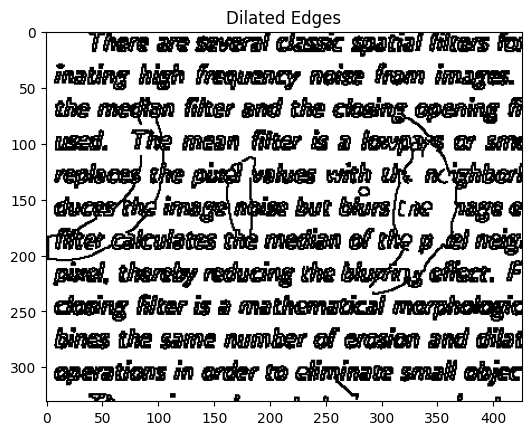

In [63]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load Image
image = cv2.imread('dirty-img.png', cv2.IMREAD_GRAYSCALE)
if image is None:
    print("Check your file path!")
else:
    # 2. Apply a light blur
    blurred = cv2.GaussianBlur(image, (3, 3), 0)

    # 3. AUTO-CANNY: Calculate thresholds automatically
    v = np.median(blurred)
    sigma = 0.33  # Standard deviation for thresholding
    lower = int(max(0, (1.0 - sigma) * v))
    upper = int(min(255, (1.0 + sigma) * v))
    
    print(f"Using thresholds: Lower={lower}, Upper={upper}")
    
    # 4. Detect Edges
    edges = cv2.Canny(blurred, lower, upper)

    # 5. Dilate (Thicken)
    kernel = np.ones((2, 2), np.uint8)
    thick_edges = cv2.dilate(edges, kernel, iterations=1)
    thick_edges = cv2.bitwise_not(thick_edges)

    # 6. Show results (Standard white on black for debugging)
    plt.imshow(thick_edges, cmap='gray')
    plt.title('Dilated Edges')
    plt.show()

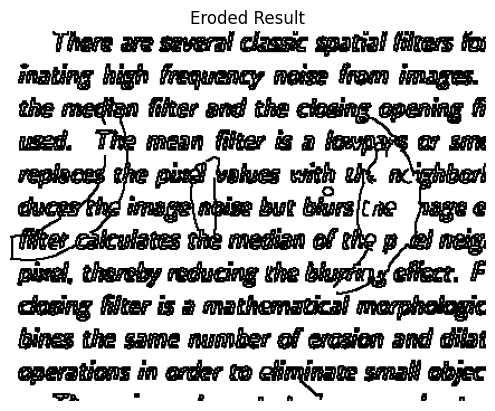

In [62]:
# 1. Define the kernel (the "eraser" size)
kernel1 = np.ones((1, 1), np.uint8)

# 2. Apply Erosion
# src: your image, kernel: the brush, iterations: how many times to erode
eroded_image = cv2.erode(thick_edges, kernel1, iterations=1)

# 3. Plot the result
plt.imshow(eroded_image, cmap='gray')
plt.title('Eroded Result')
plt.axis('off')
plt.show()